# Patch vs clean — highway brake-reaction analysis

Compare follower behavior over 10 clean vs 10 patched runs on Town04 highway.
- **Leader** (`vehicle.carlamotors.carlacola`) cruises at 40 km/h for 10 s, then hard-brakes for 5 s.
- **Follower** (`vehicle.tesla.model3`) driven by PCLA agent `tfv6_visiononly` — has to detect the leader and brake.
- The only difference between conditions: the rear panel of the leader. CLEAN = original CarlaCola red; PATCH = the adversarial TGA we trained against YOLO.

Metrics extracted: brake **reaction time** (when does follower brake > 0.2?), **minimum distance**, **collision count**, **TTC** profile.

In [1]:
import json, re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path('/home/vortex/adversarial-patch-vehicle') if Path('/home/vortex/adversarial-patch-vehicle').exists() else Path.cwd()
RUN_ROOT = REPO_ROOT / 'experiments/carla_scenarios/patch_vs_clean_20260609_115057'
CLEAN_DIR = RUN_ROOT / 'clean'
PATCH_DIR = RUN_ROOT / 'patch'
BRAKE_START_S = 10.0   # leader brakes at 10 s
BRAKE_THRESH = 0.2     # follower considered 'reacting' if brake > this
print('Clean runs:', len(list(CLEAN_DIR.glob('*/telemetry.csv'))))
print('Patch runs:', len(list(PATCH_DIR.glob('*/telemetry.csv'))))

Clean runs: 10
Patch runs: 10


In [2]:
def load_runs(label, root):
    out = []
    for d in sorted(root.glob('*/telemetry.csv')):
        run = d.parent
        tel = pd.read_csv(run / 'telemetry.csv')
        agt = pd.read_csv(run / 'agent.csv')
        summary = json.loads((run / 'summary.json').read_text())
        out.append({'label': label, 'run_dir': run, 'telemetry': tel, 'agent': agt, 'summary': summary})
    return out

clean_runs = load_runs('clean', CLEAN_DIR)
patch_runs = load_runs('patch', PATCH_DIR)
print(f'Loaded {len(clean_runs)} clean and {len(patch_runs)} patch runs')

Loaded 10 clean and 10 patch runs


In [3]:
def per_run_metrics(runs):
    rows = []
    for r in runs:
        tel, agt, s = r['telemetry'], r['agent'], r['summary']
        # Brake reaction time: first sim_time after BRAKE_START_S where brake > BRAKE_THRESH
        post = agt[agt['sim_time_s'] >= BRAKE_START_S]
        react = post[post['brake'] > BRAKE_THRESH]
        reaction_time = (react['sim_time_s'].iloc[0] - BRAKE_START_S) if len(react) > 0 else None
        # Min distance after leader brake start
        post_tel = tel[tel['sim_time_s'] >= BRAKE_START_S]
        min_dist = float(post_tel['distance_m'].min()) if len(post_tel) else None
        # Collision
        collisions = int(tel['collision_detected'].sum())
        # End follower speed
        end_follower_kmh = float(tel['follower_speed_kmh'].iloc[-1])
        rows.append({
            'run': r['run_dir'].name,
            'reaction_time_s': reaction_time,
            'min_distance_m': min_dist,
            'collisions': collisions,
            'follower_speed_end_kmh': end_follower_kmh,
        })
    return pd.DataFrame(rows)

clean_metrics = per_run_metrics(clean_runs)
patch_metrics = per_run_metrics(patch_runs)
clean_metrics['label'] = 'clean'
patch_metrics['label'] = 'patch'
all_metrics = pd.concat([clean_metrics, patch_metrics], ignore_index=True)
all_metrics

,run,reaction_time_s,min_distance_m,collisions,follower_speed_end_kmh,label
0,none_tfv6_visiononly_seed10_20260609_120105,0.00,10.806,0,7.93,clean
1,none_tfv6_visiononly_seed1_20260609_115123,0.10,10.321,0,7.34,clean
2,none_tfv6_visiononly_seed2_20260609_115229,0.00,10.503,0,3.49,clean
3,none_tfv6_visiononly_seed3_20260609_115335,0.00,10.758,1,0.00,clean
4,none_tfv6_visiononly_seed4_20260609_115439,0.30,10.375,0,3.05,clean
5,none_tfv6_visiononly_seed5_20260609_115545,0.00,10.489,0,0.00,clean
6,none_tfv6_visiononly_seed6_20260609_115650,0.15,11.191,0,0.00,clean
7,none_tfv6_visiononly_seed7_20260609_115754,0.30,10.207,1,1.31,clean
8,none_tfv6_visiononly_seed8_20260609_115900,0.30,10.326,0,0.00,clean
9,none_tfv6_visiononly_seed9_20260609_120003,0.25,10.202,0,9.02,clean


In [4]:
summary = all_metrics.groupby('label').agg(
    n_runs=('run', 'count'),
    reaction_time_mean=('reaction_time_s', 'mean'),
    reaction_time_median=('reaction_time_s', 'median'),
    min_dist_mean_m=('min_distance_m', 'mean'),
    min_dist_min_m=('min_distance_m', 'min'),
    total_collisions=('collisions', 'sum'),
    runs_with_collision=('collisions', lambda s: int((s > 0).sum())),
    follower_end_speed_mean=('follower_speed_end_kmh', 'mean'),
).round(3)
summary

,n_runs,reaction_time_mean,reaction_time_median,min_dist_mean_m,min_dist_min_m,total_collisions,runs_with_collision,follower_end_speed_mean
label,,,,,,,,
clean,10,0.140,0.125,10.518,10.202,2,2,3.214
patch,10,0.165,0.125,11.059,10.752,1,1,0.000


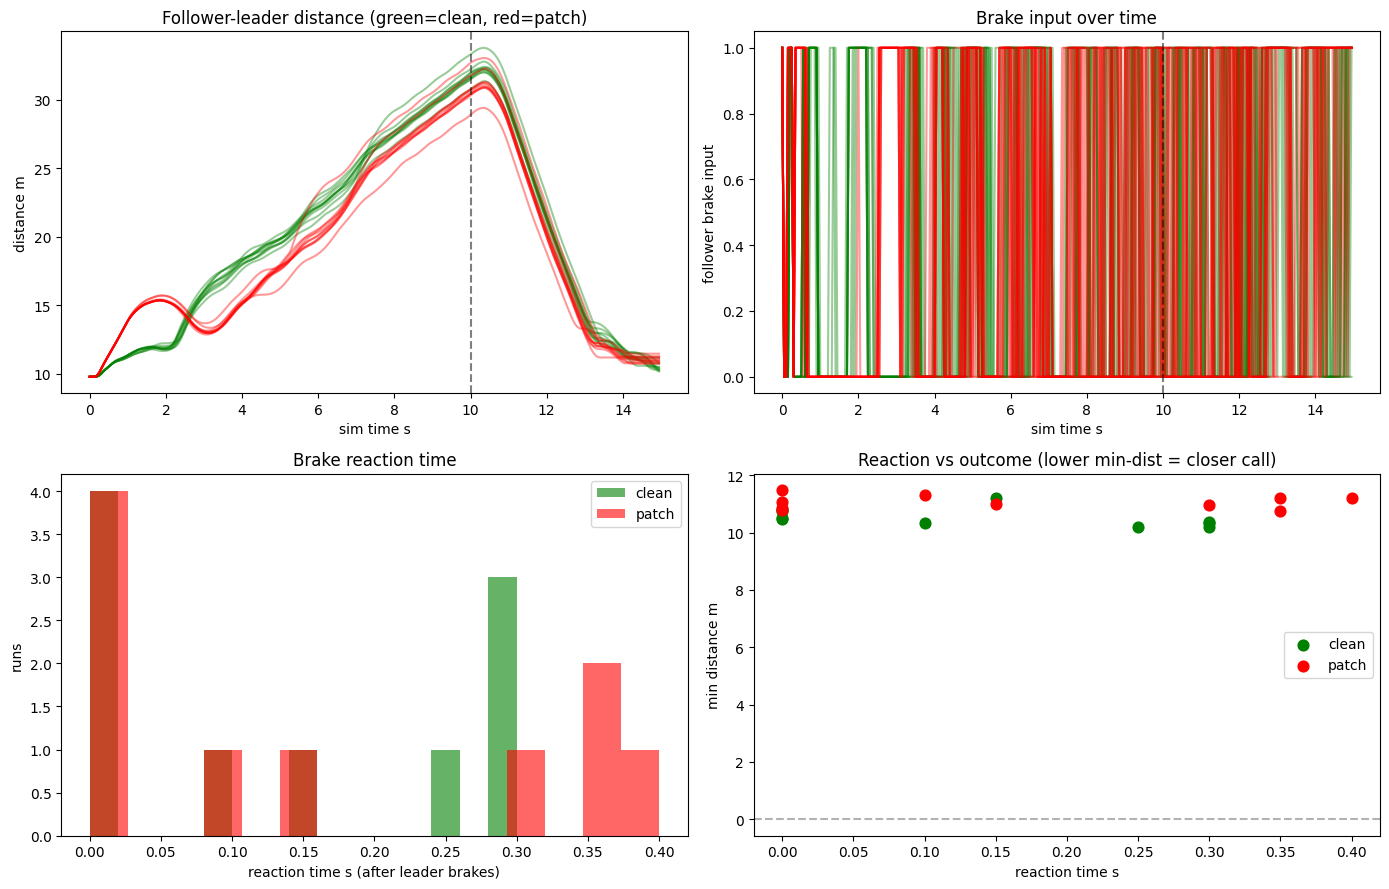

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Distance over time per run
for r in clean_runs:
    axes[0,0].plot(r['telemetry']['sim_time_s'], r['telemetry']['distance_m'], color='green', alpha=0.4)
for r in patch_runs:
    axes[0,0].plot(r['telemetry']['sim_time_s'], r['telemetry']['distance_m'], color='red', alpha=0.4)
axes[0,0].axvline(BRAKE_START_S, color='k', ls='--', alpha=0.5)
axes[0,0].set_xlabel('sim time s'); axes[0,0].set_ylabel('distance m')
axes[0,0].set_title('Follower-leader distance (green=clean, red=patch)')

# Brake input per run
for r in clean_runs:
    axes[0,1].plot(r['agent']['sim_time_s'], r['agent']['brake'], color='green', alpha=0.4)
for r in patch_runs:
    axes[0,1].plot(r['agent']['sim_time_s'], r['agent']['brake'], color='red', alpha=0.4)
axes[0,1].axvline(BRAKE_START_S, color='k', ls='--', alpha=0.5)
axes[0,1].set_xlabel('sim time s'); axes[0,1].set_ylabel('follower brake input')
axes[0,1].set_title('Brake input over time')

# Reaction time histogram
axes[1,0].hist(clean_metrics['reaction_time_s'].dropna(), bins=15, alpha=0.6, color='green', label='clean')
axes[1,0].hist(patch_metrics['reaction_time_s'].dropna(), bins=15, alpha=0.6, color='red', label='patch')
axes[1,0].set_xlabel('reaction time s (after leader brakes)'); axes[1,0].set_ylabel('runs')
axes[1,0].set_title('Brake reaction time')
axes[1,0].legend()

# Min distance vs reaction time scatter
axes[1,1].scatter(clean_metrics['reaction_time_s'], clean_metrics['min_distance_m'], color='green', label='clean', s=60)
axes[1,1].scatter(patch_metrics['reaction_time_s'], patch_metrics['min_distance_m'], color='red', label='patch', s=60)
axes[1,1].axhline(0, color='k', ls='--', alpha=0.3)
axes[1,1].set_xlabel('reaction time s'); axes[1,1].set_ylabel('min distance m')
axes[1,1].set_title('Reaction vs outcome (lower min-dist = closer call)')
axes[1,1].legend()

plt.tight_layout(); plt.show()

## Interpretation

- If the patch is working downstream, in the **red runs** we expect: later reaction time, smaller min distance, more collisions.
- A **null result** (red ≈ green) means the patch reduces YOLO confidence but not enough to alter the PCLA agent's brake decision — the agent has its own internal redundancy (depth, motion cues).
- These results were obtained with PCLA agent `tfv6_visiononly`. Want stronger transfer? Re-run with `tfv4_aim` (vision-only Transfuser v4) and `simlingo_simlingo` (VLM).

## All frames where the patch fully hid the leader from YOLO

These are paired val-set frames where YOLO sees the truck on CLEAN (`conf_clean > 0`) but loses it completely on PATCH (`conf_patched == 0`). The cleanest success cases of the attack — useful for spotting common factors (lighting, distance, weather, viewpoint).

Note: this section re-uses the trained patch (`run02`) and the paired clean/marker datasets, independently of the CARLA-side analysis above.

In [ ]:
import cv2, json, torch
from random import Random
from ultralytics import YOLO

RUN_TS_DATA = '20260609_014138'
MARKER_DIR = REPO_ROOT / 'data/chroma_key_dataset' / f'capture_{RUN_TS_DATA}_marker'
CLEAN_DIR_HIDDEN  = REPO_ROOT / 'data/chroma_key_dataset' / f'capture_{RUN_TS_DATA}_clean'
QUADS = json.loads((MARKER_DIR / 'quads_index.json').read_text())
PATCH_RUN = REPO_ROOT / 'experiments/yolo_attack/run02_20260609_093207'
PATCH = torch.load(PATCH_RUN / 'patch_final.pt', map_location='cpu').clamp(0, 1)
if PATCH.dim() == 4: PATCH = PATCH.squeeze(0)
YOLO_WEIGHTS = REPO_ROOT / 'src/vehicle_counting_model/yolov8n.pt'
yolo = YOLO(str(YOLO_WEIGHTS))
VEHICLE_CLASSES = {2: 'car', 5: 'bus', 7: 'truck'}
CONF_THRESHOLD = 0.25
EXPAND = 2.5

def order_corners(c):
    c = np.asarray(c, np.float32); s = c.sum(1); d = np.diff(c, axis=1).reshape(-1)
    return np.stack([c[np.argmin(s)], c[np.argmin(d)], c[np.argmax(s)], c[np.argmax(d)]])
def target_bbox(corners, img_shape, expand=EXPAND):
    H, W = img_shape[:2]
    cx, cy = corners[:, 0].mean(), corners[:, 1].mean()
    hw = (corners[:, 0].max() - corners[:, 0].min()) * 0.5 * expand
    hh = (corners[:, 1].max() - corners[:, 1].min()) * 0.5 * expand
    return np.array([max(0, cx - hw), max(0, cy - hh), min(W - 1, cx + hw), min(H - 1, cy + hh)], np.float32)
def warp_patch_onto(img_bgr, patch_chw, corners):
    Ph, Pw = patch_chw.shape[1], patch_chw.shape[2]
    patch_bgr = (patch_chw.permute(1, 2, 0).numpy()[..., ::-1] * 255).clip(0, 255).astype('uint8')
    src = np.array([[0, 0], [Pw - 1, 0], [Pw - 1, Ph - 1], [0, Ph - 1]], np.float32)
    dst = order_corners(corners); M = cv2.getPerspectiveTransform(src, dst)
    Hf, Wf = img_bgr.shape[:2]
    warped = cv2.warpPerspective(patch_bgr, M, (Wf, Hf))
    mask = np.ones((Ph, Pw), np.uint8) * 255
    warped_mask = cv2.warpPerspective(mask, M, (Wf, Hf))
    out = img_bgr.copy(); out[warped_mask > 0] = warped[warped_mask > 0]
    return out
def yolo_leader_detection(bgr, tbox):
    res = yolo.predict(bgr, verbose=False, conf=CONF_THRESHOLD)[0]
    if res.boxes is None or len(res.boxes) == 0: return None, 0.0, None
    cands = []
    for box, conf, cls in zip(res.boxes.xyxy.cpu().numpy(), res.boxes.conf.cpu().numpy(), res.boxes.cls.cpu().int().tolist()):
        if cls not in VEHICLE_CLASSES: continue
        cx = (box[0] + box[2]) / 2; cy = (box[1] + box[3]) / 2
        if tbox[0] <= cx <= tbox[2] and tbox[1] <= cy <= tbox[3]:
            cands.append((conf, box, cls))
    if not cands: return None, 0.0, None
    cands.sort(reverse=True, key=lambda t: t[0])
    return cands[0][1], float(cands[0][0]), VEHICLE_CLASSES[cands[0][2]]
def draw_box(bgr, box, conf, cls, color):
    img = bgr.copy()
    if box is None: return img
    x1, y1, x2, y2 = box.astype(int)
    cv2.rectangle(img, (x1, y1), (x2, y2), color, 3)
    cv2.putText(img, f'{cls} {conf:.2f}', (x1, max(0, y1 - 8)), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)
    return img

# Same val split as the training/eval setup
rng = Random(0)
all_stems = sorted(QUADS.keys())
rng.shuffle(all_stems)
n_val = int(0.2 * len(all_stems))
val_stems = sorted(all_stems[:n_val])
print(f'val set: {len(val_stems)} frames')

In [ ]:
# Identify frames where YOLO sees the leader CLEAN but the patch hides it.
hidden_stems = []
hidden_meta = []
for i, stem in enumerate(val_stems):
    if i % 50 == 0: print(f'  scanning {i}/{len(val_stems)}', flush=True)
    cp = CLEAN_DIR_HIDDEN / f'{stem}.png'
    mp = MARKER_DIR / f'{stem}.png'
    if not cp.exists() or not mp.exists(): continue
    clean_bgr = cv2.imread(str(cp)); marker_bgr = cv2.imread(str(mp))
    corners = np.asarray(QUADS[stem]['corners'], np.float32)
    tbox = target_bbox(corners, clean_bgr.shape)
    patched_bgr = warp_patch_onto(marker_bgr, PATCH, corners)
    _, cc, kc = yolo_leader_detection(clean_bgr, tbox)
    _, cp_, _ = yolo_leader_detection(patched_bgr, tbox)
    if cc > 0 and cp_ == 0:
        hidden_stems.append(stem)
        hidden_meta.append({'stem': stem, 'conf_clean': cc, 'cls_clean': kc})
print(f'Hidden frames: {len(hidden_stems)}')
pd.DataFrame(hidden_meta)

In [ ]:
n = len(hidden_stems)
if n > 0:
    fig, axes = plt.subplots(n, 2, figsize=(16, 4 * n))
    if n == 1: axes = np.array([axes])
    for row, stem in enumerate(hidden_stems):
        clean_bgr = cv2.imread(str(CLEAN_DIR_HIDDEN / f'{stem}.png'))
        marker_bgr = cv2.imread(str(MARKER_DIR / f'{stem}.png'))
        corners = np.asarray(QUADS[stem]['corners'], np.float32)
        tbox = target_bbox(corners, clean_bgr.shape)
        patched_bgr = warp_patch_onto(marker_bgr, PATCH, corners)
        box_c, conf_c, cls_c = yolo_leader_detection(clean_bgr, tbox)
        ic = draw_box(clean_bgr, box_c, conf_c, cls_c or 'none', (0, 220, 0))
        ip = patched_bgr.copy()
        cv2.putText(ip, 'HIDDEN', (40, 60), cv2.FONT_HERSHEY_SIMPLEX, 1.6, (0, 0, 255), 4)
        axes[row, 0].imshow(cv2.cvtColor(ic, cv2.COLOR_BGR2RGB))
        axes[row, 0].set_title(f'{stem} CLEAN  conf={conf_c:.3f}  cls={cls_c}', fontsize=10)
        axes[row, 0].axis('off')
        axes[row, 1].imshow(cv2.cvtColor(ip, cv2.COLOR_BGR2RGB))
        axes[row, 1].set_title(f'{stem} PATCH  HIDDEN', fontsize=10)
        axes[row, 1].axis('off')
    plt.tight_layout(); plt.show()
else:
    print('No hidden frames in this run.')